# Fitness Tracker Data Analysis
### Objective
This project analyzes daily fitness tracker data to understand user activity patterns, sedentary behavior, and calorie expenditure.

### Goals
- Clean and prepare the dataset
- Perform exploratory data analysis
- Identify behavioral patterns in physical activity
- Detect outliers and unusual activity
- Generate user-level insights

## 1. Data Loading

I begin by loading the dataset containing daily activity information collected from wearable fitness trackers.

In [17]:
import os
os.listdir()

['.ipynb_checkpoints',
 'dailyActivity_merged.csv',
 'data_cleaning.ipynb',
 'hourlyCalories_merged.csv',
 'hourlyIntensities_merged.csv',
 'hourlySteps_merged.csv',
 'sleepDay_merged.csv',
 'weightLogInfo_merged.csv']

In [2]:
import pandas as pd
daily = pd.read_csv("dailyActivity_merged.csv")
daily.head(10)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863
5,1503960366,4/17/2016,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,38,20,164,539,1728
6,1503960366,4/18/2016,13019,8.59,8.59,0.0,3.25,0.64,4.71,0.0,42,16,233,1149,1921
7,1503960366,4/19/2016,15506,9.88,9.88,0.0,3.53,1.32,5.03,0.0,50,31,264,775,2035
8,1503960366,4/20/2016,10544,6.68,6.68,0.0,1.96,0.48,4.24,0.0,28,12,205,818,1786
9,1503960366,4/21/2016,9819,6.34,6.34,0.0,1.34,0.35,4.65,0.0,19,8,211,838,1775


## 2. Initial Data Exploration

I inspect the structure of the dataset including the number of rows, columns, data types, and potential duplicates.

In [3]:
daily.shape

(940, 15)

In [4]:

daily.columns
daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

In [5]:
daily.duplicated().sum()

np.int64(0)

## 3. Data Cleaning

To ensure accurate analysis, I perform the following cleaning steps:

- Convert date columns to datetime format
- Identify inactive days
- Remove days where the tracker recorded zero steps

In [6]:
daily["ActivityDate"] = pd.to_datetime(daily["ActivityDate"])

In [7]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes  

In [8]:
daily["DayOfWeek"] = daily["ActivityDate"].dt.day_name()

In [9]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes  

In [10]:
daily.head(2)


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,DayOfWeek
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,Tuesday
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,Wednesday


In [11]:
daily.describe()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,9.400000e+02,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,2016-04-26 06:53:37.021276672,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,2016-04-19 00:00:00,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000
50%,4.445115e+09,2016-04-26 00:00:00,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000
75%,6.962181e+09,2016-05-04 00:00:00,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000
std,2.424805e+09,NaN,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862


In [12]:
(daily["TotalSteps"] == 0).sum()

np.int64(77)

In [13]:
daily[daily["TotalSteps"] == 0].head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,DayOfWeek
30,1503960366,2016-05-12,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,0,Thursday
104,1844505072,2016-04-24,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,1347,Sunday
105,1844505072,2016-04-25,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,1347,Monday
106,1844505072,2016-04-26,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,1347,Tuesday
112,1844505072,2016-05-02,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,1348,Monday


In [16]:
daily_clean = daily[daily['TotalSteps'] > 0]  

In [17]:
print(daily_clean.describe())

                 Id                   ActivityDate    TotalSteps  \
count  8.630000e+02                            863    863.000000   
mean   4.857542e+09  2016-04-26 02:16:49.501738240   8319.392816   
min    1.503960e+09            2016-04-12 00:00:00      4.000000   
25%    2.320127e+09            2016-04-18 00:00:00   4923.000000   
50%    4.445115e+09            2016-04-26 00:00:00   8053.000000   
75%    6.962181e+09            2016-05-03 00:00:00  11092.500000   
max    8.877689e+09            2016-05-12 00:00:00  36019.000000   
std    2.418405e+09                            NaN   4744.967224   

       TotalDistance  TrackerDistance  LoggedActivitiesDistance  \
count     863.000000       863.000000                863.000000   
mean        5.979513         5.963882                  0.117822   
min         0.000000         0.000000                  0.000000   
25%         3.370000         3.370000                  0.000000   
50%         5.590000         5.590000               

In [18]:
daily_clean.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,DayOfWeek
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,Tuesday
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,Wednesday
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,Thursday
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,Friday
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,Saturday


## 4. Exploratory Data Analysis

This section explores patterns in daily activity including step distribution, calories burned, and activity intensity.

In [19]:
daily_raw = daily.copy() 

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
sns.set(style="whitegrid")

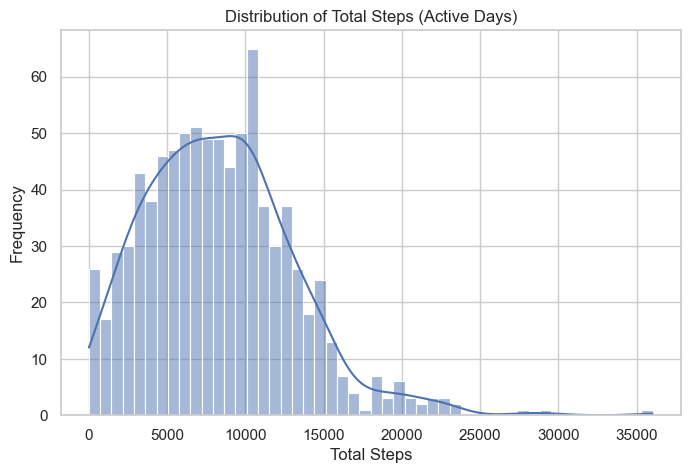

In [22]:
# 5.1 Distribution of Total Steps
plt.figure(figsize=(8,5))
sns.histplot(daily_clean['TotalSteps'], bins=50, kde=True)
plt.title("Distribution of Total Steps (Active Days)")
plt.xlabel("Total Steps")
plt.ylabel("Frequency")
plt.show()


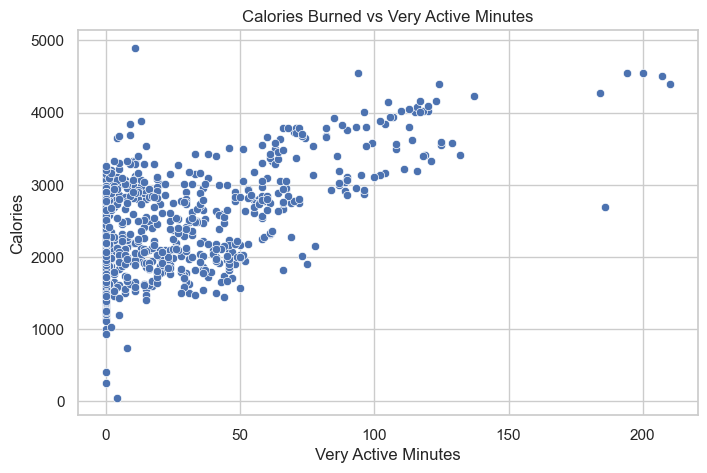

In [23]:
# 5.2 Calories vs Very Active Minutes
plt.figure(figsize=(8,5))
sns.scatterplot(x='VeryActiveMinutes', y='Calories', data=daily_clean)
plt.title("Calories Burned vs Very Active Minutes")
plt.xlabel("Very Active Minutes")
plt.ylabel("Calories")
plt.show()

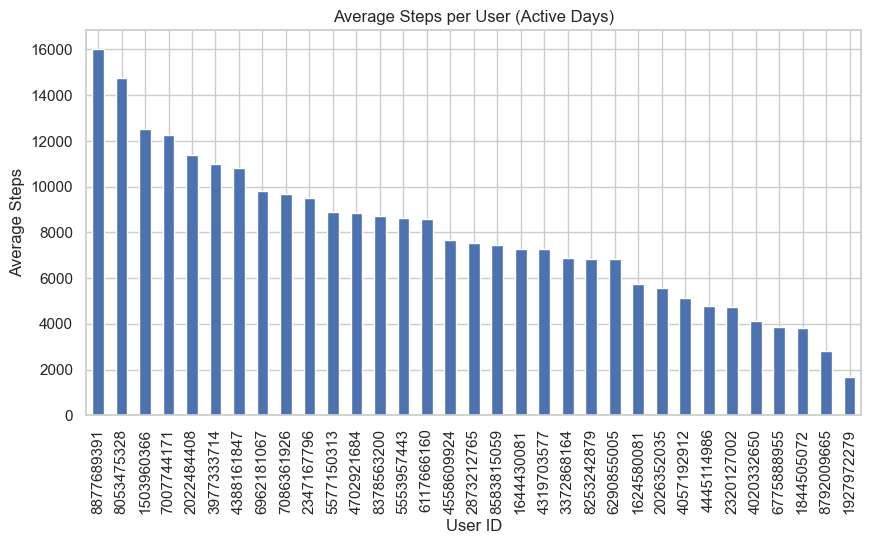

In [24]:
# 5.3 Average steps per user
avg_steps_per_user = daily_clean.groupby('Id')['TotalSteps'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
avg_steps_per_user.plot(kind='bar')
plt.title("Average Steps per User (Active Days)")
plt.xlabel("User ID")
plt.ylabel("Average Steps")
plt.show()


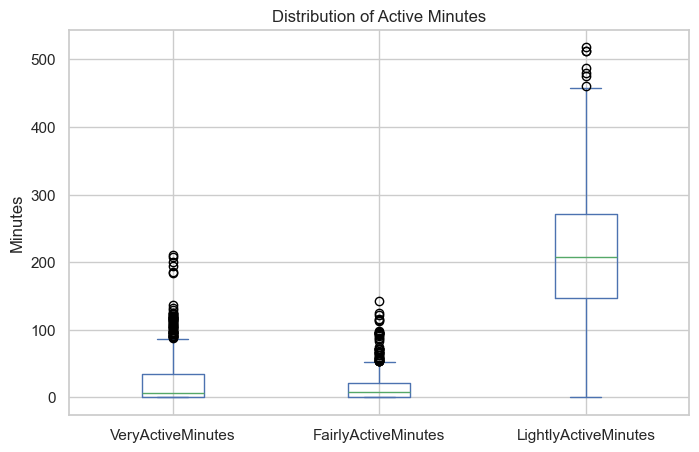

In [25]:
# 5.4 Active Minutes Breakdown
active_minutes_cols = ['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes']
daily_clean[active_minutes_cols].plot(kind='box', figsize=(8,5))
plt.title("Distribution of Active Minutes")
plt.ylabel("Minutes")
plt.show()



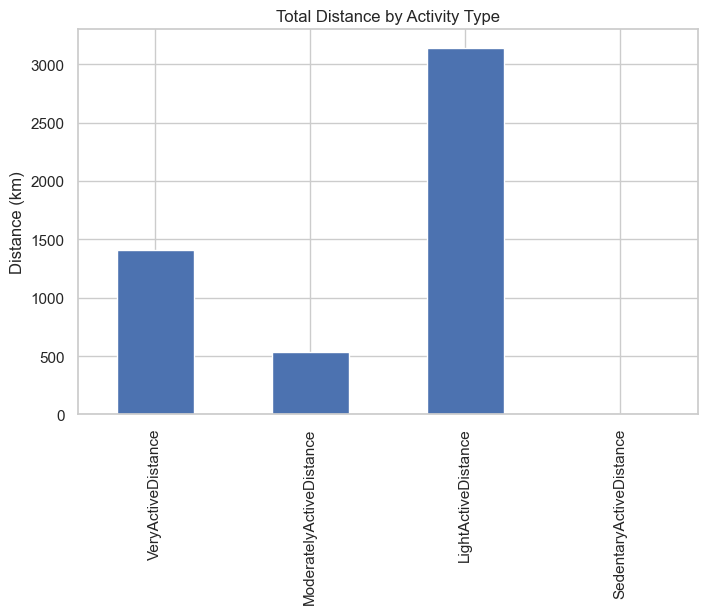

In [26]:
# 5.5 Distance by Activity Type
distance_cols = ['VeryActiveDistance','ModeratelyActiveDistance','LightActiveDistance','SedentaryActiveDistance']
daily_clean[distance_cols].sum().plot(kind='bar', figsize=(8,5))
plt.title("Total Distance by Activity Type")
plt.ylabel("Distance (km)")
plt.show()

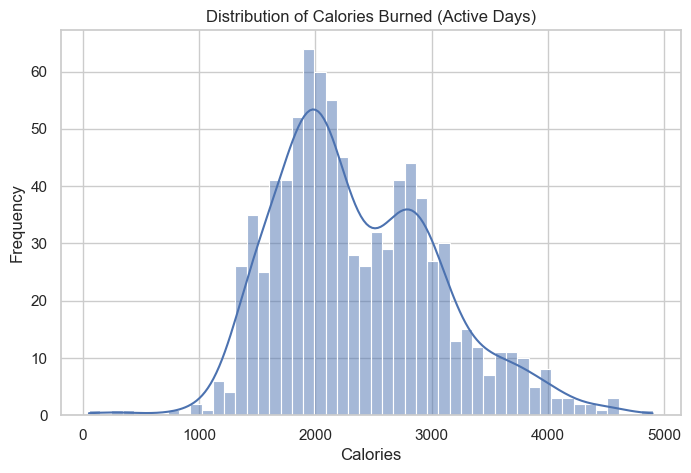

In [27]:
# 5.6 Calories statistics
plt.figure(figsize=(8,5))
sns.histplot(daily_clean['Calories'], bins=50, kde=True)
plt.title("Distribution of Calories Burned (Active Days)")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

## 5. Inactive Day Analysis

Inactive days represent periods where users either did not wear their trackers or had extremely low activity. Understanding this behaviour helps identify user engagement with the device.

In [28]:
# -----------------------------
# 6. Inactive-day analysis (zero-step rows)
# -----------------------------
inactive_daily = daily_raw[daily_raw['TotalSteps'] == 0]


In [29]:
# Total inactive days
print("Total inactive days:", inactive_daily.shape[0])

Total inactive days: 77


In [30]:
# Inactive days per user
inactive_per_user = inactive_daily.groupby('Id').size()
print("\nInactive days per user:\n", inactive_per_user)




Inactive days per user:
 Id
1503960366     1
1844505072    10
1927972279    14
4020332650    14
4057192912     1
4702921684     1
5577150313     2
6117666160     5
6290855005     5
6775888955     9
7007744171     2
7086361926     1
8253242879     1
8583815059     1
8792009665    10
dtype: int64


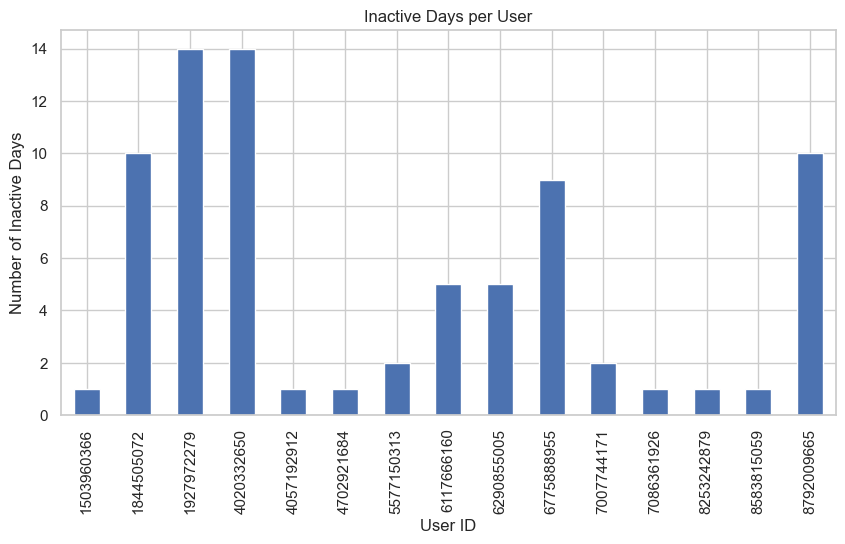

In [31]:
# Visualization: Inactive days per user
plt.figure(figsize=(10,5))
inactive_per_user.plot(kind='bar')
plt.title("Inactive Days per User")
plt.xlabel("User ID")
plt.ylabel("Number of Inactive Days")
plt.show()

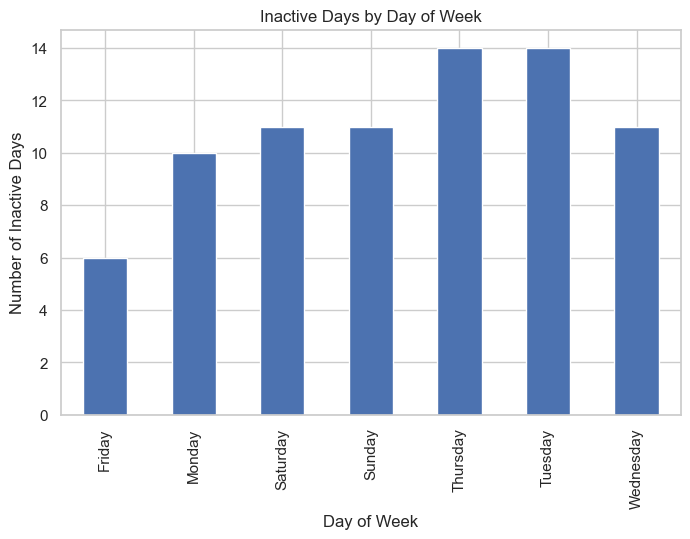

In [32]:
# Visualization: Inactive days by day of week
plt.figure(figsize=(8,5))
inactive_daily['DayOfWeek'].value_counts().sort_index().plot(kind='bar')
plt.title("Inactive Days by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Inactive Days")
plt.show()

### Outlier Detection Using Boxplots

Boxplots were used to visually inspect the distribution of key activity metrics and identify potential outliers. 
Outliers may represent unusually high physical activity days or data recording anomalies.

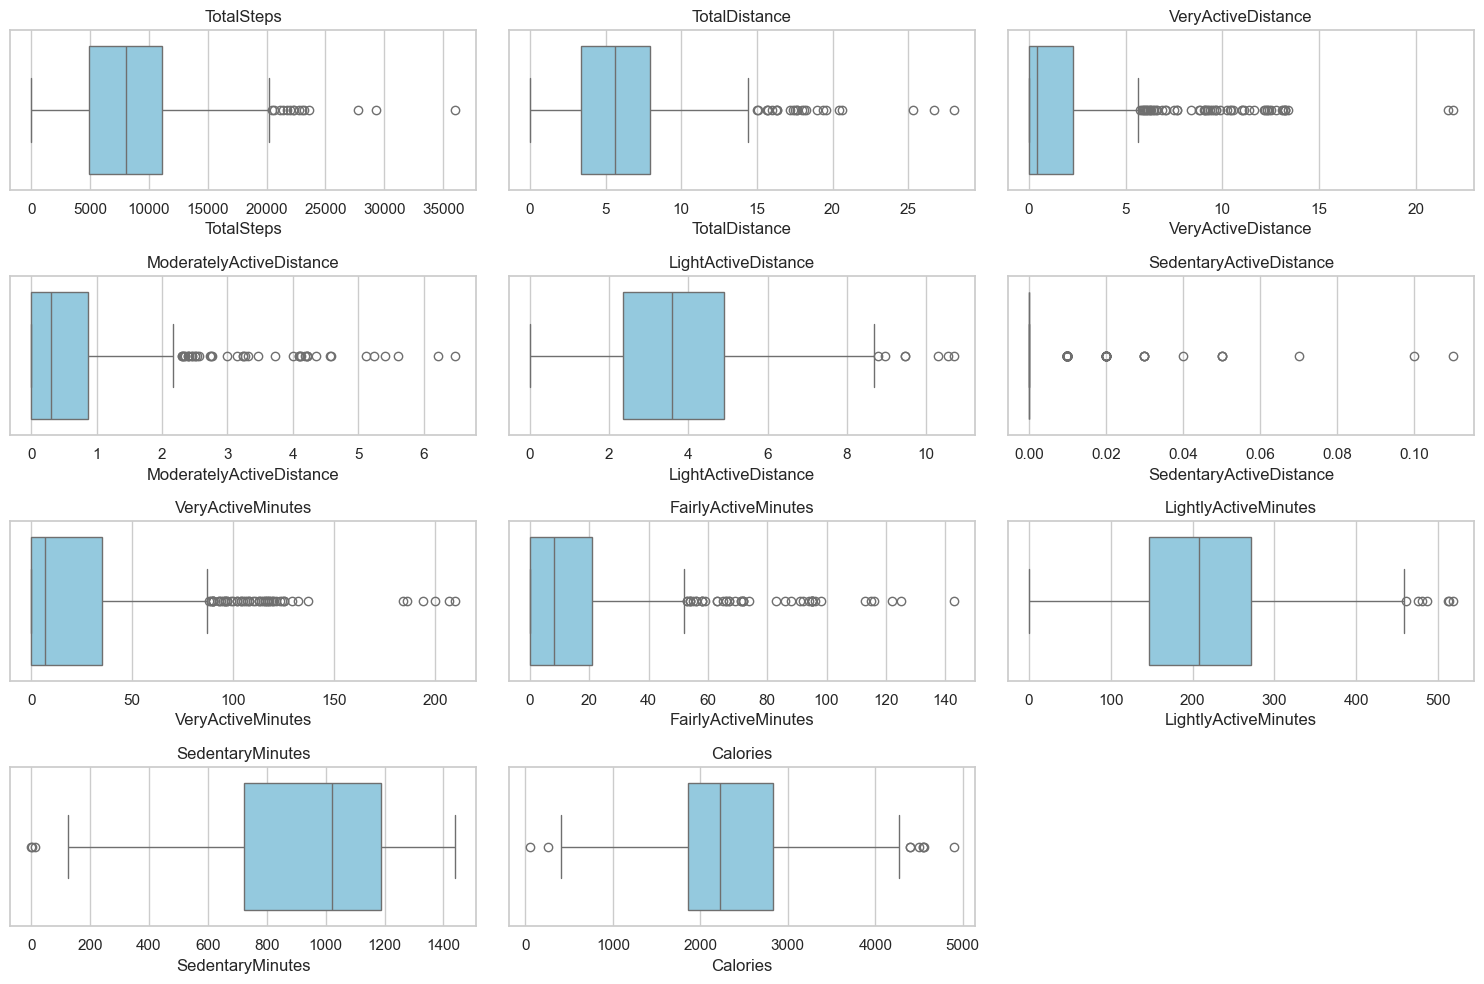

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'TotalSteps','TotalDistance','VeryActiveDistance','ModeratelyActiveDistance',
    'LightActiveDistance','SedentaryActiveDistance','VeryActiveMinutes',
    'FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes','Calories'
]

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4,3,i+1)
    sns.boxplot(x=daily_clean[col], color="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()

## 6. Outlier Detection Using Z-Score Method

To identify unusually high or low activity values, I applied the Z-score method for outlier detection.
The Z-score measures how many standard deviations a data point is from the mean.
Observations with |Z-score| greater than 3 are considered extreme outliers and are removed to create a cleaned dataset for reliable analysis.
We also store the detected outliers separately for further investigation.

In [34]:
from scipy import stats
import numpy as np

# Calculate z-scores
z_scores = np.abs(stats.zscore(daily_clean[numeric_cols]))

# Keep rows where all z-scores < 3 (typical cutoff)
daily_clean_advanced = daily_clean[(z_scores < 3).all(axis=1)]

print("Rows before removing outliers:", daily_clean.shape[0])
print("Rows after removing outliers:", daily_clean_advanced.shape[0])

Rows before removing outliers: 863
Rows after removing outliers: 792


In [35]:
# Separate outliers for special analysis
z_scores = np.abs(stats.zscore(daily_clean[numeric_cols]))
daily_clean_outliers = daily_clean[(z_scores > 3).any(axis=1)]

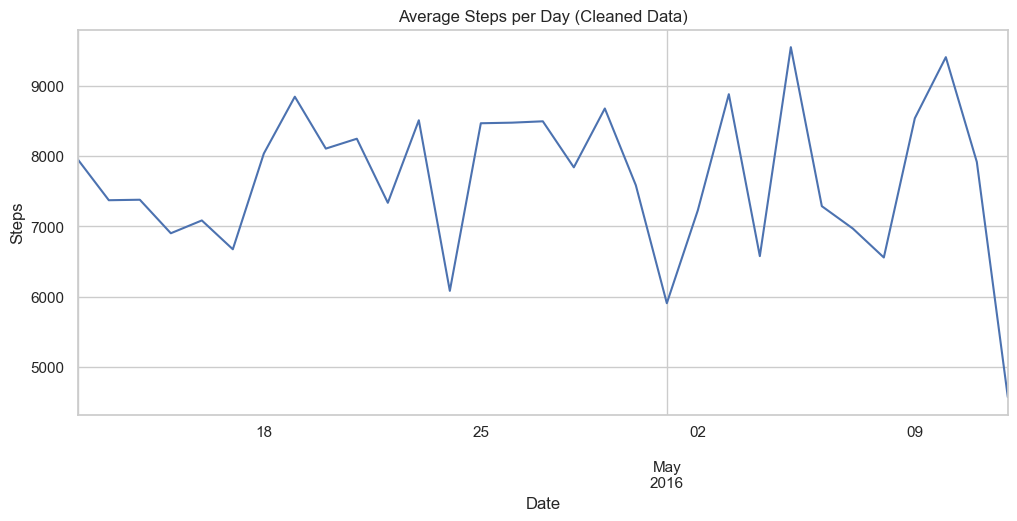

In [36]:
# Average steps per date (general trend)
daily_clean_advanced.groupby('ActivityDate')['TotalSteps'].mean().plot(figsize=(12,5))
plt.title("Average Steps per Day (Cleaned Data)")
plt.xlabel("Date")
plt.ylabel("Steps")
plt.show()

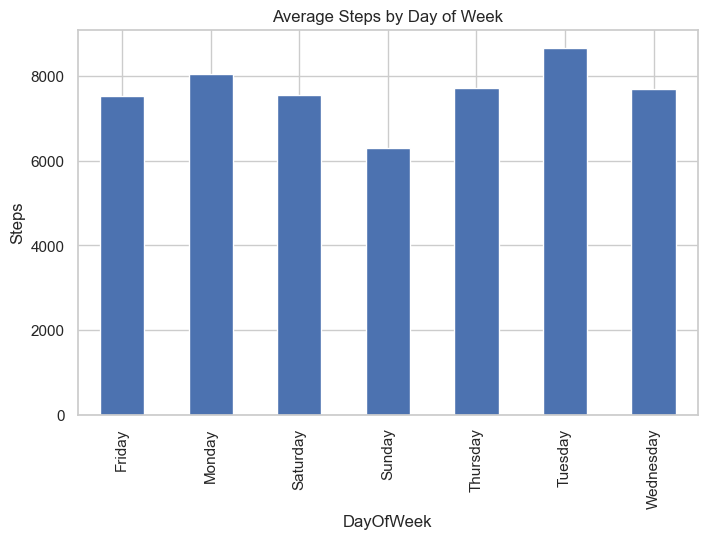

In [37]:
daily_clean_advanced.groupby('DayOfWeek')['TotalSteps'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Average Steps by Day of Week")
plt.ylabel("Steps")
plt.show()

## 7. Correlation Analysis

I examine relationships between key activity metrics such as steps, calories burned, and active minutes.

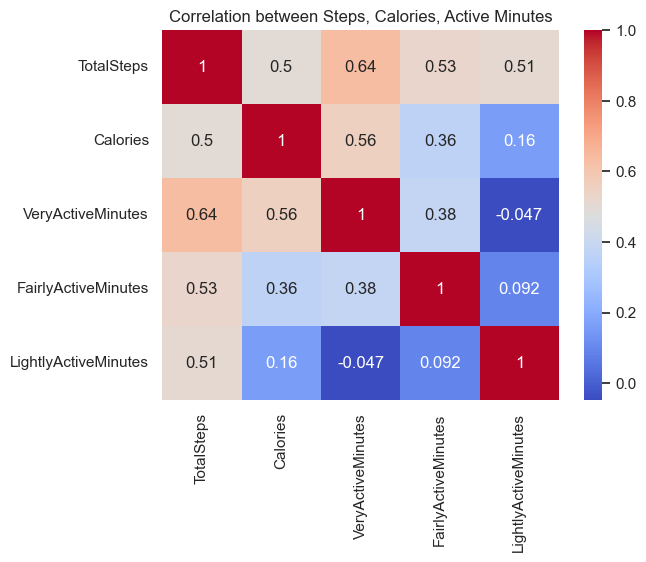

In [40]:
numeric_cols = ['TotalSteps','Calories','VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes']
corr = daily_clean_advanced[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between Steps, Calories, Active Minutes")
plt.show()

In [41]:
# Top outlier rows
daily_clean_outliers[['Id','ActivityDate','TotalSteps','Calories','VeryActiveMinutes']].sort_values('TotalSteps', ascending=False)

,Id,ActivityDate,TotalSteps,Calories,VeryActiveMinutes
50,1624580081,2016-05-01,36019,2690,186
913,8877689391,2016-04-16,29326,4547,94
927,8877689391,2016-04-30,27745,4398,124
924,8877689391,2016-04-27,23629,3808,93
909,8877689391,2016-04-12,23186,3921,85
...,...,...,...,...,...
374,4020332650,2016-05-10,5546,2926,0
367,4020332650,2016-05-03,4496,2828,0
345,3977333714,2016-05-11,746,52,4
264,2347167796,2016-04-29,42,403,0


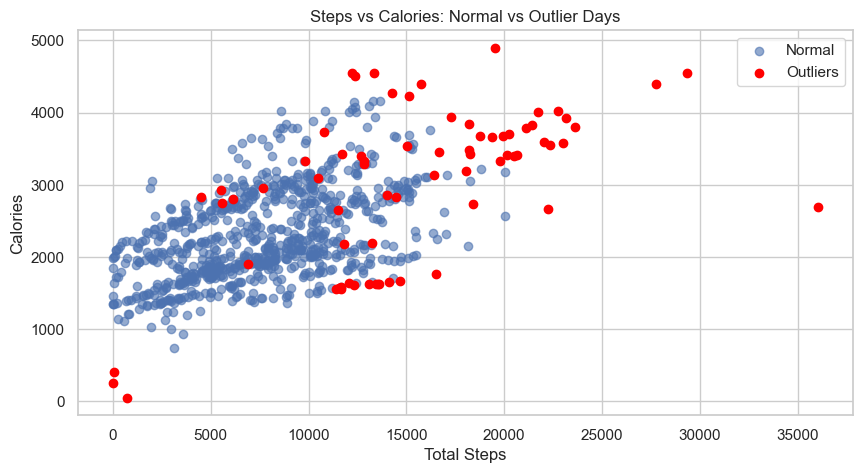

In [42]:
plt.figure(figsize=(10,5))
plt.scatter(daily_clean_advanced['TotalSteps'], daily_clean_advanced['Calories'], label='Normal', alpha=0.6)
plt.scatter(daily_clean_outliers['TotalSteps'], daily_clean_outliers['Calories'], color='red', label='Outliers')
plt.xlabel("Total Steps")
plt.ylabel("Calories")
plt.title("Steps vs Calories: Normal vs Outlier Days")
plt.legend()
plt.show()

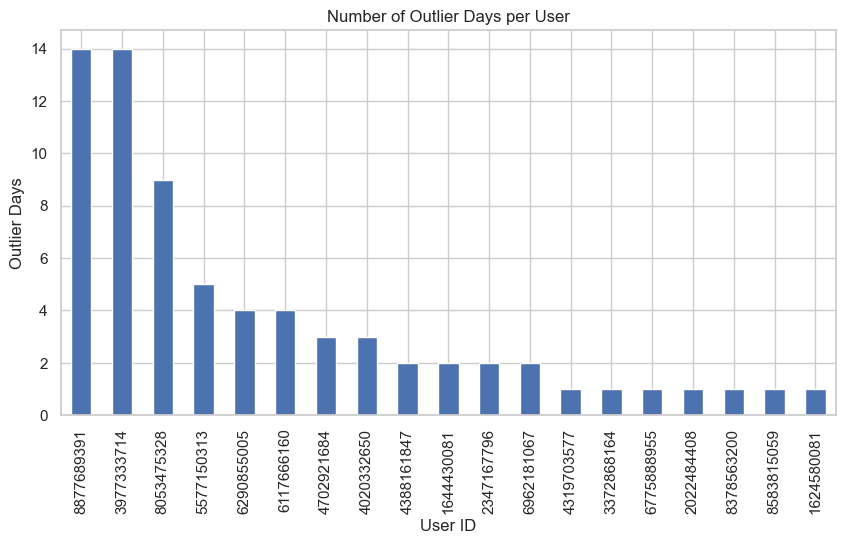

In [43]:
daily_clean_outliers['Id'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Number of Outlier Days per User")
plt.xlabel("User ID")
plt.ylabel("Outlier Days")
plt.show()

In [56]:
daily_clean.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'DayOfWeek'],
      dtype='object')

In [58]:
daily_clean.loc[:, 'TotalActiveMinutes'] = (
    daily_clean['VeryActiveMinutes'] +
    daily_clean['FairlyActiveMinutes'] +
    daily_clean['LightlyActiveMinutes']
)

In [60]:
user_summary = daily_clean.groupby('Id').agg({
    'TotalSteps': 'mean',
    'Calories': 'mean',
    'TotalActiveMinutes': 'mean',
    'SedentaryMinutes': 'mean'
})

user_summary.head()

,TotalSteps,Calories,TotalActiveMinutes,SedentaryMinutes
Id,,,,
1503960366,12520.633333,1876.966667,287.066667,828.433333
1624580081,5743.903226,1483.354839,167.967742,1257.741935
1644430081,7282.966667,2811.300000,209.400000,1161.866667
1844505072,3808.666667,1713.761905,172.523810,1130.190476
1927972279,1670.588235,2303.058824,74.176471,1244.352941


In [61]:
user_summary.sort_values('TotalSteps', ascending=False)

,TotalSteps,Calories,TotalActiveMinutes,SedentaryMinutes
Id,,,,
8877689391,16040.032258,3420.258065,310.709677,1112.870968
8053475328,14763.290323,2945.806452,245.709677,1148.000000
1503960366,12520.633333,1876.966667,287.066667,828.433333
7007744171,12267.041667,2686.125000,355.375000,1078.666667
2022484408,11370.645161,2509.967742,313.096774,1112.580645
3977333714,10984.566667,1513.666667,254.933333,707.533333
4388161847,10813.935484,3093.870968,272.870968,836.677419
6962181067,9794.806452,1982.032258,287.129032,662.322581
7086361926,9684.166667,2597.600000,218.833333,830.800000


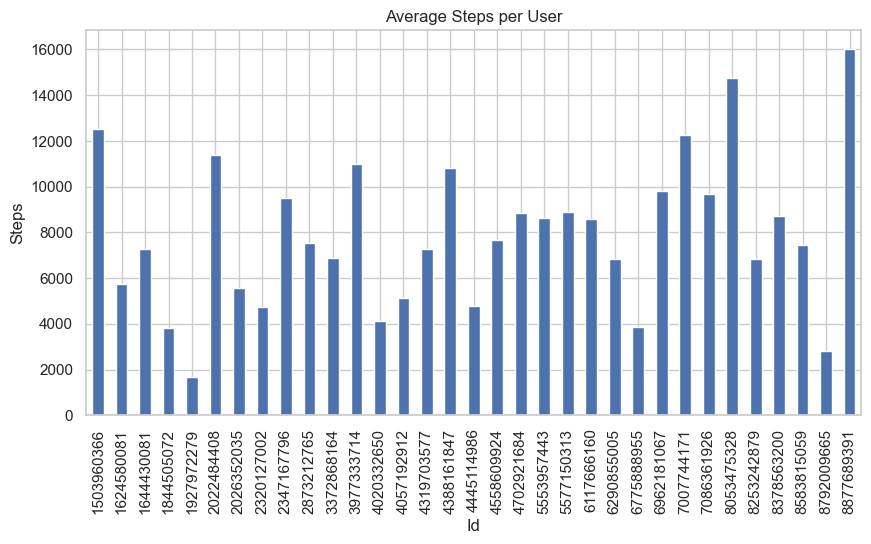

In [62]:
user_summary['TotalSteps'].plot(kind='bar', figsize=(10,5))

plt.title("Average Steps per User")
plt.ylabel("Steps")

plt.show()

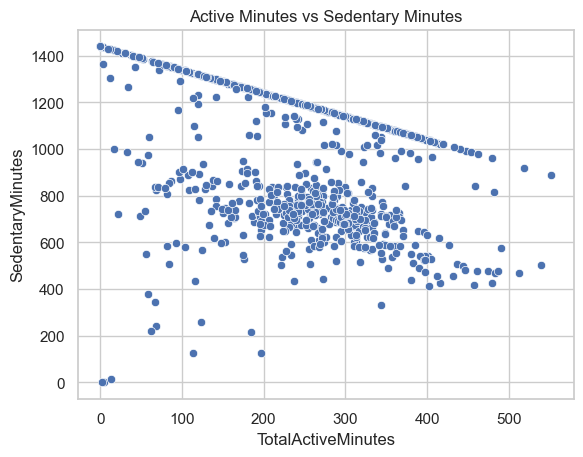

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x='TotalActiveMinutes',
    y='SedentaryMinutes',
    data=daily_clean
)

plt.title("Active Minutes vs Sedentary Minutes")

plt.show()

In [66]:
daily_clean.loc[:, 'SedentaryRatio'] = (
    daily_clean['SedentaryMinutes'] /
    (daily_clean['TotalActiveMinutes'] + daily_clean['SedentaryMinutes'])
)

In [68]:
daily_clean['SedentaryRatio'].describe()

count    863.000000
mean       0.782004
std        0.106011
min        0.000000
25%        0.725000
50%        0.777083
75%        0.847477
max        1.000000
Name: SedentaryRatio, dtype: float64

In [ ]:
daily_clean['SedentaryRatio'].hist(bins=20)

plt.title("Sedentary Lifestyle Ratio Distribution")

plt.show()

## Key Insights

1. **User Activity Levels Are Highly Uneven**

The distribution of daily step counts indicates significant variability in user activity levels. While some users consistently achieve high step counts, a large portion of observations fall within moderate ranges, suggesting that overall activity levels differ widely across individuals rather than following a uniform behavioral pattern.

2. **High-Intensity Activity Strongly Influences Calorie Expenditure**

The relationship between Very Active Minutes and Calories Burned shows a clear positive association, indicating that high-intensity activity contributes disproportionately to daily energy expenditure. Users who accumulate more very active minutes tend to burn substantially more calories, highlighting the impact of vigorous movement on overall fitness outcomes.

3. **Light Activity Dominates Daily Movement Patterns**

The distribution of active minutes suggests that most user movement occurs in light-intensity activity, while minutes categorized as **very active or fairly active occur far less frequently. This indicates that daily movement for most users is driven by routine activities such as walking, commuting, or general mobility rather than structured workouts.

4. **Physical Distance Is Primarily Generated by Low-Intensity Movement**

The total distance breakdown across activity types shows that light activity contributes the largest share of total distance traveled**, whereas high-intensity movement contributes a smaller portion. This reinforces the pattern that most users accumulate movement through regular daily behavior rather than concentrated exercise sessions.

5. **Significant User-Level Variability Exists in Daily Step Performance**

The comparison of average steps per user reveals noticeable differences in activity habits across individuals. Some users consistently record substantially higher step counts than others, indicating that lifestyle, routine, and engagement with physical activity vary considerably across the participant base.

6. **Sedentary Behavior Remains a Major Component of Daily Time Allocation**

Despite the presence of active minutes, a substantial portion of recorded time is still classified as sedentary. This suggests that while users do engage in physical movement throughout the day, long periods of inactivity remain common within the daily activity cycle.

7. **Inactive Days Provide Behavioral Insight Rather Than Data Noise**

The presence of zero-step days highlights periods where users either did not wear their device or recorded no measurable activity. Rather than being purely data errors, these inactive days may reflect realistic patterns such as device non-usage, illness, or extremely sedentary days, and therefore offer additional context when interpreting overall activity trends.

---

## Conclusion

Overall, the daily activity dataset reveals that user movement patterns are largely driven by routine low-intensity activity rather than sustained high-intensity exercise. While certain individuals demonstrate high levels of physical activity, the broader user base appears to accumulate movement gradually throughout the day. At the same time, sedentary behavior remains prevalent, suggesting that opportunities exist to encourage more consistent and sustained physical activity within daily routines.

# 7. Sleep Data Cleaning and Analysis
*This section explores users' sleep patterns, including total sleep duration,
time spent in bed, and sleep efficiency.*


## Load Sleep Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
sleep = pd.read_csv("sleepDay_merged.csv")
sleep.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


## Inspect Dataset Structure

In [4]:
sleep.shape
sleep.info()
sleep.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  413 non-null    int64 
 1   SleepDay            413 non-null    object
 2   TotalSleepRecords   413 non-null    int64 
 3   TotalMinutesAsleep  413 non-null    int64 
 4   TotalTimeInBed      413 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 16.3+ KB


np.int64(3)

## Remove Duplicate Records

In [5]:
sleep = sleep.drop_duplicates()
sleep.duplicated().sum()

np.int64(0)

## Convert SleepDay to Datetime

In [7]:
sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"], format="%m/%d/%Y %I:%M:%S %p")

In [8]:
sleep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 410 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  410 non-null    int64         
 1   SleepDay            410 non-null    datetime64[ns]
 2   TotalSleepRecords   410 non-null    int64         
 3   TotalMinutesAsleep  410 non-null    int64         
 4   TotalTimeInBed      410 non-null    int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 19.2 KB


## Extract Date Column

In [9]:
sleep["Date"] = sleep["SleepDay"].dt.date

## Convert Sleep Minutes to Hours

In [10]:
sleep["HoursAsleep"] = sleep["TotalMinutesAsleep"] / 60
sleep["HoursInBed"] = sleep["TotalTimeInBed"] / 60

## Sleep Duration Distribution

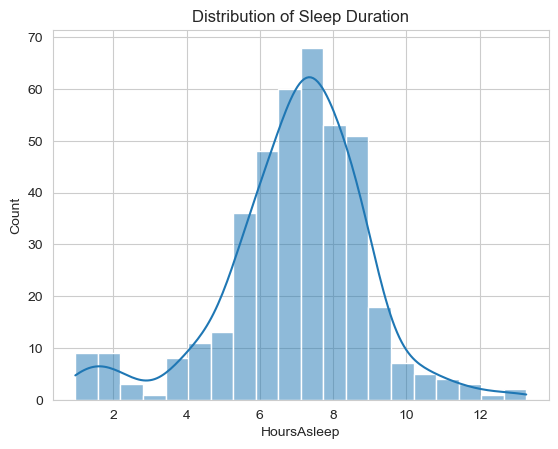

In [11]:
sns.histplot(sleep["HoursAsleep"], bins=20, kde=True)
plt.title("Distribution of Sleep Duration")
plt.show()

## Time in Bed vs Sleep Duration

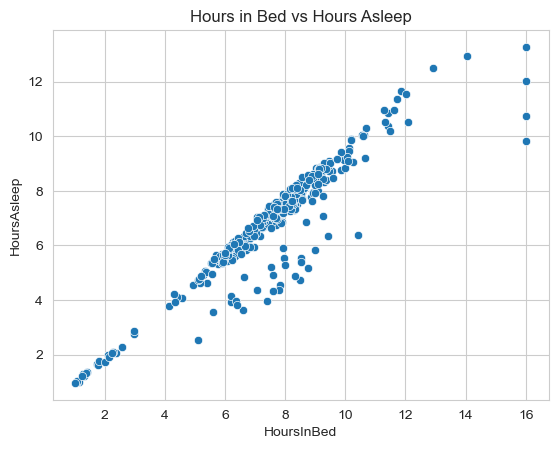

In [12]:
sns.scatterplot(data=sleep, x="HoursInBed", y="HoursAsleep")
plt.title("Hours in Bed vs Hours Asleep")
plt.show()

## Calculate Sleep Efficiency

In [13]:
sleep["SleepEfficiency"] = sleep["TotalMinutesAsleep"] / sleep["TotalTimeInBed"]

## Sleep Efficiency Distribution

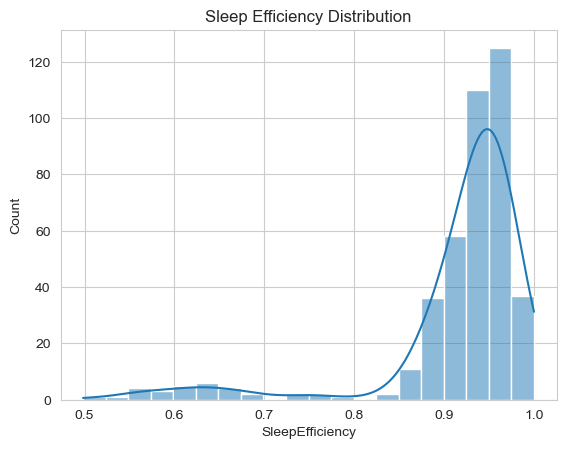

In [14]:
sns.histplot(sleep["SleepEfficiency"], bins=20, kde=True)
plt.title("Sleep Efficiency Distribution")
plt.show()

In [15]:
 sleep["HoursAsleep"].describe()

count    410.000000
mean       6.986220
std        1.977265
min        0.966667
25%        6.016667
50%        7.208333
75%        8.166667
max       13.266667
Name: HoursAsleep, dtype: float64

## Key Insights

1. The dataset contains 410 valid sleep records, with an average sleep duration of approximately 7 hours, indicating that most users maintain a moderate and relatively healthy sleep duration pattern.

2. Sleep duration is largely concentrated between 6 and 8 hours, as reflected by the median sleep duration of about 7.2 hours. This suggests that the majority of users follow fairly consistent and stable sleep routines rather than experiencing highly irregular sleep cycles.

3. Sleep efficiency across the dataset is generally very high, with most values concentrated around 0.9–1.0. This indicates that users typically spend most of their time in bed actually sleeping, suggesting relatively efficient sleep behavior among the participants.

4. The scatter plot between Hours in Bed and Hours Asleep shows a strong positive relationship, indicating that increases in time spent in bed generally translate directly into longer sleep duration rather than prolonged wakefulness.

5. While most observations follow consistent sleep patterns, a small number of extreme values exist, including very low sleep durations (around 1 hour) and unusually long sleep durations exceeding 12–13 hours. These observations may represent irregular user behavior, recovery sleep, or potential tracking anomalies.

6. Overall, the sleep dataset suggests that although the majority of users maintain stable sleep habits with high sleep efficiency, a minority of extreme observations could influence overall statistical trends and should be interpreted with caution.

# Hourly Steps Data Analysis

In [16]:
hourly_steps = pd.read_csv("hourlySteps_merged.csv")
hourly_steps.head()

,Id,ActivityHour,StepTotal
0,1503960366,4/12/2016 12:00:00 AM,373
1,1503960366,4/12/2016 1:00:00 AM,160
2,1503960366,4/12/2016 2:00:00 AM,151
3,1503960366,4/12/2016 3:00:00 AM,0
4,1503960366,4/12/2016 4:00:00 AM,0


## Inspect the Dataset

In [19]:
hourly_steps.shape
hourly_steps.info()
hourly_steps.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            22099 non-null  int64 
 1   ActivityHour  22099 non-null  object
 2   StepTotal     22099 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 518.1+ KB


np.int64(0)

## Convert ActivityHour to Datetime

In [21]:
hourly_steps["ActivityHour"] = pd.to_datetime(
    hourly_steps["ActivityHour"],
    format="%m/%d/%Y %I:%M:%S %p"
)

In [22]:
hourly_steps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Id            22099 non-null  int64         
 1   ActivityHour  22099 non-null  datetime64[ns]
 2   StepTotal     22099 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 518.1 KB


### Extract Hour and Day Features

In [23]:
hourly_steps["Hour"] = hourly_steps["ActivityHour"].dt.hour
hourly_steps["DayOfWeek"] = hourly_steps["ActivityHour"].dt.day_name()

hourly_steps.head()

,Id,ActivityHour,StepTotal,Hour,DayOfWeek
0,1503960366,2016-04-12 00:00:00,373,0,Tuesday
1,1503960366,2016-04-12 01:00:00,160,1,Tuesday
2,1503960366,2016-04-12 02:00:00,151,2,Tuesday
3,1503960366,2016-04-12 03:00:00,0,3,Tuesday
4,1503960366,2016-04-12 04:00:00,0,4,Tuesday


## Average Steps by Hour of the Day

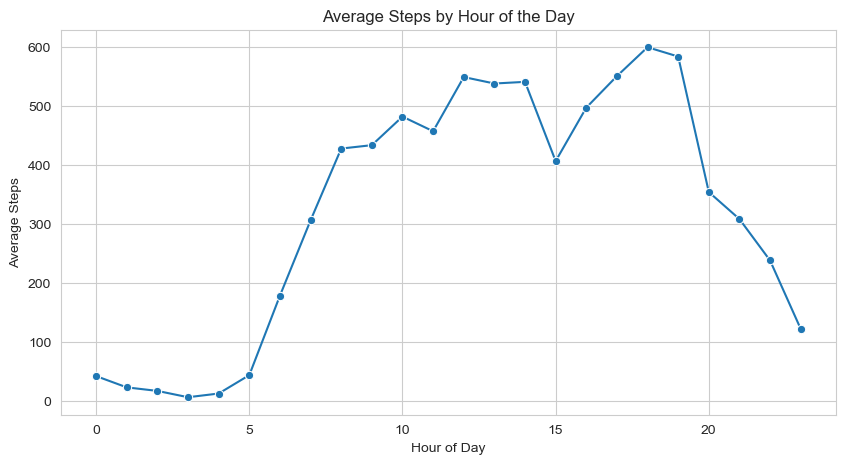

In [24]:
steps_by_hour = hourly_steps.groupby("Hour")["StepTotal"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=steps_by_hour, x="Hour", y="StepTotal", marker="o")

plt.title("Average Steps by Hour of the Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Steps")

plt.show()

## Average Steps by Day of Week

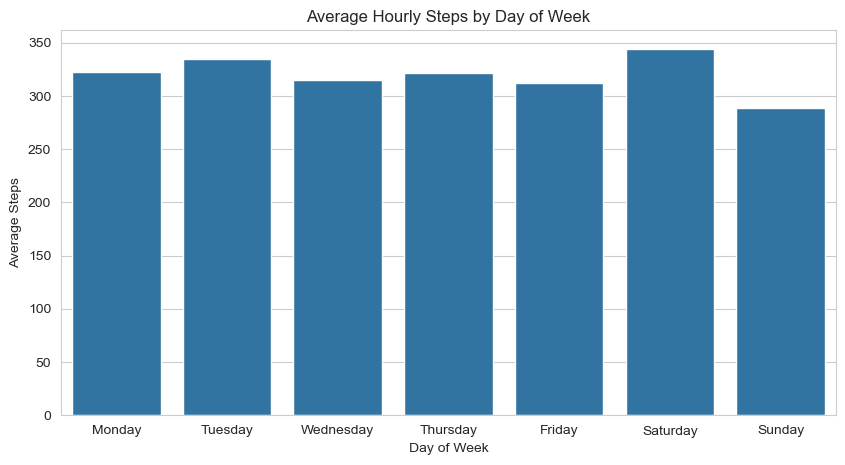

In [25]:
steps_by_day = hourly_steps.groupby("DayOfWeek")["StepTotal"].mean().reset_index()

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

plt.figure(figsize=(10,5))
sns.barplot(data=steps_by_day, x="DayOfWeek", y="StepTotal", order=order)

plt.title("Average Hourly Steps by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Steps")

plt.show()

## Distribution of Hourly Steps

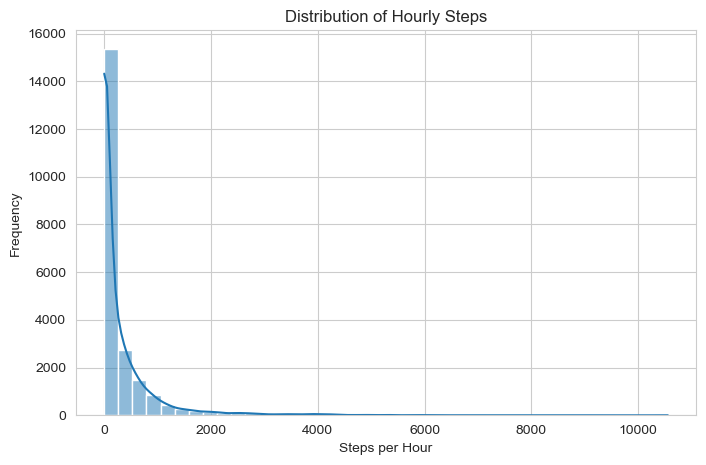

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(hourly_steps["StepTotal"], bins=40, kde=True)

plt.title("Distribution of Hourly Steps")
plt.xlabel("Steps per Hour")
plt.ylabel("Frequency")

plt.show()

## Key Insights

1. **Daily Activity Follows a Clear Behavioral Rhythm**

The hourly step trend reveals a strong daily activity cycle. Step counts remain extremely low during the night and early morning hours (12 AM – 5 AM), reflecting sleep and inactivity periods. Activity begins to increase rapidly after 6 AM, indicating the start of daily routines such as commuting, walking to work, or morning activities.

2. **Peak Physical Activity Occurs in the Early Evening**

The highest average hourly step counts occur between approximately **5 PM and 7 PM**, where activity reaches its daily peak. This pattern likely reflects post-work movement, exercise routines, commuting, or evening recreational activities.

3. **Daytime Movement Remains Consistently Moderate**

From late morning to mid-afternoon, step counts stabilize at moderate levels. This suggests that users maintain steady movement during typical daytime hours rather than experiencing sharp fluctuations in activity.

4. **Weekend Activity Shows a Different Behavioral Pattern**

Among all days, **Saturday records the highest average hourly step count**, indicating increased physical movement during leisure periods. In contrast, **Sunday shows the lowest activity levels**, suggesting that users tend to reduce movement and adopt a more relaxed routine.

5. **Physical Activity is Highly Uneven Across Time**

The distribution of hourly steps is heavily right-skewed, meaning most recorded hours involve very low step counts while high activity periods occur much less frequently. This indicates that physical movement is concentrated in specific periods rather than being evenly distributed throughout the day.

---

## Conclusion

Overall, the hourly step data highlights clear behavioral patterns in user movement. Physical activity tends to follow structured daily routines, with minimal movement during night hours, increasing activity during morning transitions, steady movement throughout the day, and peak activity during early evening hours.

Additionally, weekly patterns suggest that while weekday activity remains relatively stable, weekend behavior differs slightly, with increased movement on Saturdays and reduced activity on Sundays. The highly skewed distribution of step counts further indicates that most hours are sedentary, with meaningful physical activity occurring during shorter, concentrated periods of the day.

# Hourly Calories Analysis

In [27]:
hourly_calories = pd.read_csv("hourlyCalories_merged.csv")
hourly_calories.head()

,Id,ActivityHour,Calories
0,1503960366,4/12/2016 12:00:00 AM,81
1,1503960366,4/12/2016 1:00:00 AM,61
2,1503960366,4/12/2016 2:00:00 AM,59
3,1503960366,4/12/2016 3:00:00 AM,47
4,1503960366,4/12/2016 4:00:00 AM,48


In [28]:
hourly_calories.shape
hourly_calories.info()
hourly_calories.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            22099 non-null  int64 
 1   ActivityHour  22099 non-null  object
 2   Calories      22099 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 518.1+ KB


np.int64(0)

## Convert ActivityHour to Datetime

In [29]:
hourly_calories["ActivityHour"] = pd.to_datetime(
    hourly_calories["ActivityHour"],
    format="%m/%d/%Y %I:%M:%S %p"
)

hourly_calories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Id            22099 non-null  int64         
 1   ActivityHour  22099 non-null  datetime64[ns]
 2   Calories      22099 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 518.1 KB


In [31]:
hourly_calories["Hour"] = hourly_calories["ActivityHour"].dt.hour
hourly_calories.head()

,Id,ActivityHour,Calories,Hour
0,1503960366,2016-04-12 00:00:00,81,0
1,1503960366,2016-04-12 01:00:00,61,1
2,1503960366,2016-04-12 02:00:00,59,2
3,1503960366,2016-04-12 03:00:00,47,3
4,1503960366,2016-04-12 04:00:00,48,4


## Average Calories Burned by Hour of the Day

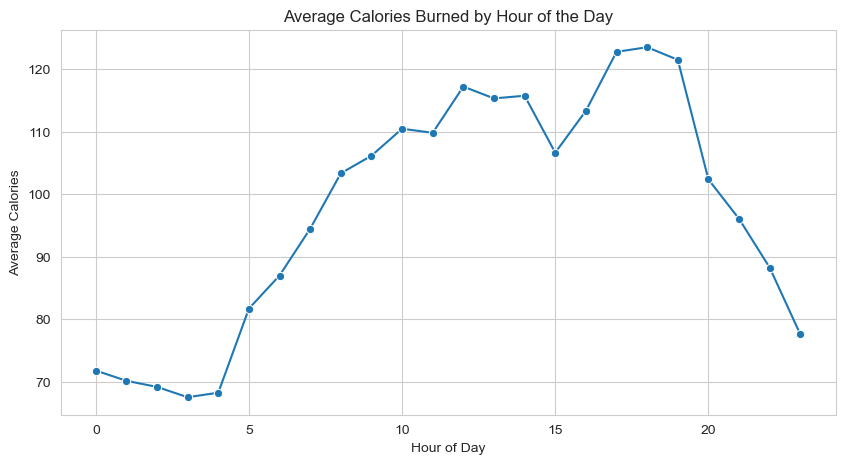

In [32]:
calories_by_hour = hourly_calories.groupby("Hour")["Calories"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=calories_by_hour, x="Hour", y="Calories", marker="o")

plt.title("Average Calories Burned by Hour of the Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Calories")

plt.show()

## Distribution of Hourly Calories

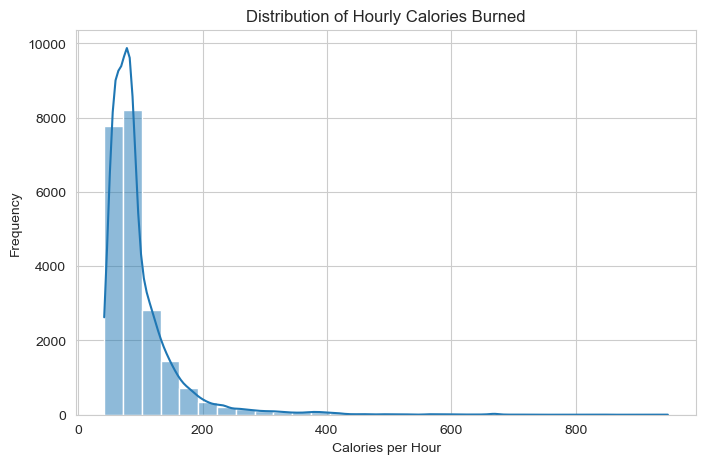

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(hourly_calories["Calories"], bins=30, kde=True)

plt.title("Distribution of Hourly Calories Burned")
plt.xlabel("Calories per Hour")
plt.ylabel("Frequency")

plt.show()

## Key Insights

1. **Calorie expenditure follows a clear daily rhythm**

The hourly calorie trend closely mirrors daily activity patterns. Calorie burn remains relatively low during early morning hours when users are largely inactive, gradually increases during the morning, and reaches its highest levels in the late afternoon and early evening. This pattern suggests that users expend the most energy during typical active hours such as commuting, exercise, or evening activities.

2. **Energy expenditure peaks during the evening period**

The highest average calorie burn occurs during the early evening hours, indicating that users tend to perform more physically demanding activities later in the day. This could reflect post-work exercise routines, recreational activities, or increased movement after work hours.

3. **Low calorie expenditure dominates most hourly observations**

The calorie distribution shows a strong concentration of observations at lower calorie values, indicating that most hours involve relatively low energy expenditure. This suggests that users spend a large portion of their day in low-intensity or sedentary states.

4. **High calorie burn events occur but are relatively rare**

While the majority of hourly observations show moderate calorie expenditure, the distribution also reveals a small number of high-calorie events. These likely correspond to periods of intense physical activity such as workouts, running, or sustained physical movement.

5. **Energy expenditure patterns align with observed movement trends**

When compared with the hourly steps analysis, calorie burn appears to increase during the same time periods where step activity rises. This reinforces the relationship between physical movement and calorie expenditure within the dataset.

# Hourly Intensities Analysis

In [34]:
hourly_intensities = pd.read_csv("hourlyIntensities_merged.csv")
hourly_intensities.head()

,Id,ActivityHour,TotalIntensity,AverageIntensity
0,1503960366,4/12/2016 12:00:00 AM,20,0.333333
1,1503960366,4/12/2016 1:00:00 AM,8,0.133333
2,1503960366,4/12/2016 2:00:00 AM,7,0.116667
3,1503960366,4/12/2016 3:00:00 AM,0,0.000000
4,1503960366,4/12/2016 4:00:00 AM,0,0.000000


In [35]:
hourly_intensities.shape
hourly_intensities.info()
hourly_intensities.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                22099 non-null  int64  
 1   ActivityHour      22099 non-null  object 
 2   TotalIntensity    22099 non-null  int64  
 3   AverageIntensity  22099 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 690.7+ KB


np.int64(0)

## Convert ActivityHour to Datetime

In [36]:
hourly_intensities["ActivityHour"] = pd.to_datetime(
    hourly_intensities["ActivityHour"],
    format="%m/%d/%Y %I:%M:%S %p"
)

hourly_intensities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Id                22099 non-null  int64         
 1   ActivityHour      22099 non-null  datetime64[ns]
 2   TotalIntensity    22099 non-null  int64         
 3   AverageIntensity  22099 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 690.7 KB


## Extract Hour Feature

In [37]:
hourly_intensities["Hour"] = hourly_intensities["ActivityHour"].dt.hour
hourly_intensities.head()

,Id,ActivityHour,TotalIntensity,AverageIntensity,Hour
0,1503960366,2016-04-12 00:00:00,20,0.333333,0
1,1503960366,2016-04-12 01:00:00,8,0.133333,1
2,1503960366,2016-04-12 02:00:00,7,0.116667,2
3,1503960366,2016-04-12 03:00:00,0,0.000000,3
4,1503960366,2016-04-12 04:00:00,0,0.000000,4


## Average Activity Intensity by Hour

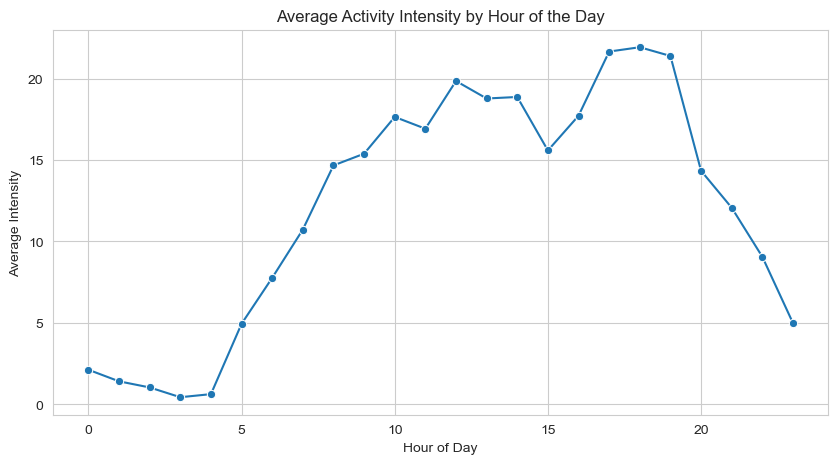

In [38]:
intensity_by_hour = hourly_intensities.groupby("Hour")["TotalIntensity"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=intensity_by_hour, x="Hour", y="TotalIntensity", marker="o")

plt.title("Average Activity Intensity by Hour of the Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Intensity")

plt.show()

 ## Distribution of Activity Intensity

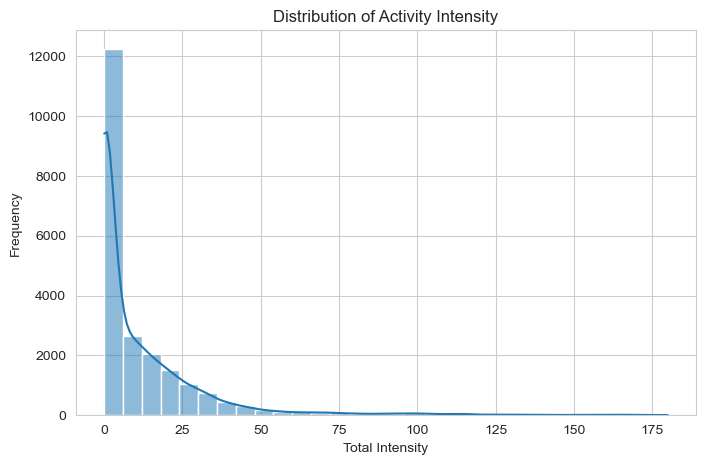

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(hourly_intensities["TotalIntensity"], bins=30, kde=True)

plt.title("Distribution of Activity Intensity")
plt.xlabel("Total Intensity")
plt.ylabel("Frequency")

plt.show()

## Key Insights

1. **User activity intensity follows a strong daily behavioral cycle**

The hourly intensity trend shows very low activity levels during late night and early morning hours (0–5 AM), indicating that most users are inactive during typical sleeping hours. Intensity gradually increases from the morning and peaks during the late afternoon and early evening (around 5–7 PM), suggesting that users are most physically active during post-work hours.

2. **Peak physical activity occurs in the evening period**

The highest activity intensity levels are observed between **17:00 and 19:00**, indicating that many users perform workouts, outdoor activities, or higher-movement routines during this period. This pattern aligns closely with common daily routines where exercise and commuting activities occur after work or school hours.

3. **Most recorded hours consist of low-intensity movement**

The intensity distribution shows a strong right-skewed pattern, where the majority of recorded hours fall within **low intensity ranges**. This suggests that most user activity consists of light movement such as walking, routine daily tasks, or sedentary behavior, while high-intensity activities occur less frequently.

4. **High-intensity activity occurs in short bursts**

Although low-intensity activity dominates the dataset, the distribution also reveals a smaller number of hours with significantly higher intensity values. These represent short periods of vigorous physical activity such as workouts, running sessions, or high-effort exercise.

5. **Intensity patterns reinforce trends observed in steps and calorie datasets**

The hourly intensity pattern closely mirrors the patterns observed in the hourly steps and hourly calories datasets. Periods with higher intensity also correspond to higher step counts and increased calorie expenditure, reinforcing the reliability of the dataset and confirming that these metrics are strongly correlated measures of physical activity.

# Weight Dataset Analysis 

In [53]:
weight = pd.read_csv("weightLogInfo_merged.csv")
weight.head()

,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,5/2/2016 11:59:59 PM,52.599998,115.963147,22.0,22.650000,True,1462233599000
1,1503960366,5/3/2016 11:59:59 PM,52.599998,115.963147,NaN,22.650000,True,1462319999000
2,1927972279,4/13/2016 1:08:52 AM,133.500000,294.317120,NaN,47.540001,False,1460509732000
3,2873212765,4/21/2016 11:59:59 PM,56.700001,125.002104,NaN,21.450001,True,1461283199000
4,2873212765,5/12/2016 11:59:59 PM,57.299999,126.324875,NaN,21.690001,True,1463097599000


In [54]:
weight.info()
weight.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              67 non-null     int64  
 1   Date            67 non-null     object 
 2   WeightKg        67 non-null     float64
 3   WeightPounds    67 non-null     float64
 4   Fat             2 non-null      float64
 5   BMI             67 non-null     float64
 6   IsManualReport  67 non-null     bool   
 7   LogId           67 non-null     int64  
dtypes: bool(1), float64(4), int64(2), object(1)
memory usage: 3.9+ KB


np.int64(0)

## Clean Weight Dataset

In [56]:
weight["Date"] = pd.to_datetime(
    weight["Date"],
    format="%m/%d/%Y %I:%M:%S %p"
).dt.date

weight_clean = weight.drop(columns=["Fat","IsManualReport","LogId"])

weight_clean.head()

,Id,Date,WeightKg,WeightPounds,BMI
0,1503960366,2016-05-02,52.599998,115.963147,22.650000
1,1503960366,2016-05-03,52.599998,115.963147,22.650000
2,1927972279,2016-04-13,133.500000,294.317120,47.540001
3,2873212765,2016-04-21,56.700001,125.002104,21.450001
4,2873212765,2016-05-12,57.299999,126.324875,21.690001


# Dataset Integration and Combined Analysis

## Prepare Sleep Dataset for Merging

In [41]:
sleep["Date"] = sleep["SleepDay"].dt.date
sleep.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,Date,HoursAsleep,HoursInBed,SleepEfficiency
0,1503960366,2016-04-12,1,327,346,2016-04-12,5.450000,5.766667,0.945087
1,1503960366,2016-04-13,2,384,407,2016-04-13,6.400000,6.783333,0.943489
2,1503960366,2016-04-15,1,412,442,2016-04-15,6.866667,7.366667,0.932127
3,1503960366,2016-04-16,2,340,367,2016-04-16,5.666667,6.116667,0.926431
4,1503960366,2016-04-17,1,700,712,2016-04-17,11.666667,11.866667,0.983146


## Prepare Activity Dataset

In [43]:
daily_activity = pd.read_csv("dailyActivity_merged.csv")
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [46]:
daily_activity["ActivityDate"] = pd.to_datetime(
    daily_activity["ActivityDate"],
    format="%m/%d/%Y"
)

In [47]:
daily_activity["Date"] = daily_activity["ActivityDate"].dt.date
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Date
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-12
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2016-04-13
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,2016-04-14
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,2016-04-15
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2016-04-16


In [48]:
merged_data = pd.merge(
    daily_activity,
    sleep,
    how="inner",
    left_on=["Id","Date"],
    right_on=["Id","Date"]
)

merged_data.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,SedentaryMinutes,Calories,Date,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,HoursAsleep,HoursInBed,SleepEfficiency
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,...,728,1985,2016-04-12,2016-04-12,1,327,346,5.450000,5.766667,0.945087
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,776,1797,2016-04-13,2016-04-13,2,384,407,6.400000,6.783333,0.943489
2,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,...,726,1745,2016-04-15,2016-04-15,1,412,442,6.866667,7.366667,0.932127
3,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,...,773,1863,2016-04-16,2016-04-16,2,340,367,5.666667,6.116667,0.926431
4,1503960366,2016-04-17,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,...,539,1728,2016-04-17,2016-04-17,1,700,712,11.666667,11.866667,0.983146


## Relationship Between Sleep Duration and Daily Steps

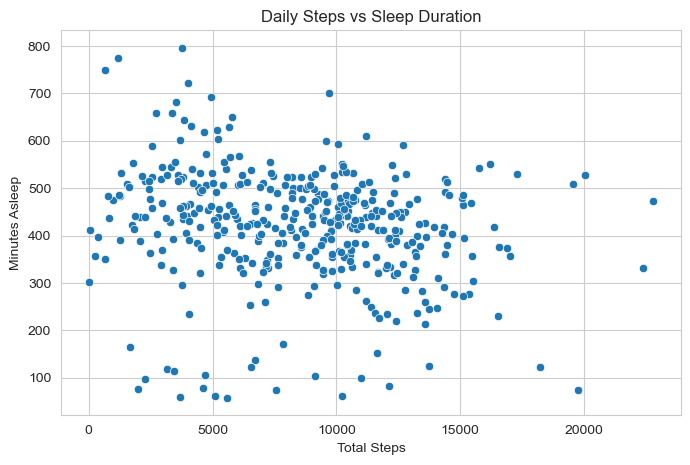

In [49]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged_data,
    x="TotalSteps",
    y="TotalMinutesAsleep"
)

plt.title("Daily Steps vs Sleep Duration")
plt.xlabel("Total Steps")
plt.ylabel("Minutes Asleep")

plt.show()

## Sedentary Behavior vs Sleep Duration

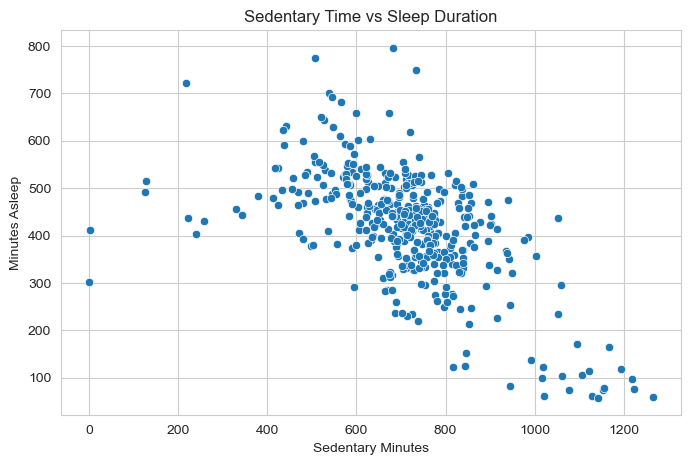

In [51]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged_data,
    x="SedentaryMinutes",
    y="TotalMinutesAsleep"
)

plt.title("Sedentary Time vs Sleep Duration")
plt.xlabel("Sedentary Minutes")
plt.ylabel("Minutes Asleep")

plt.show()

## Sleep Duration vs Time in Bed

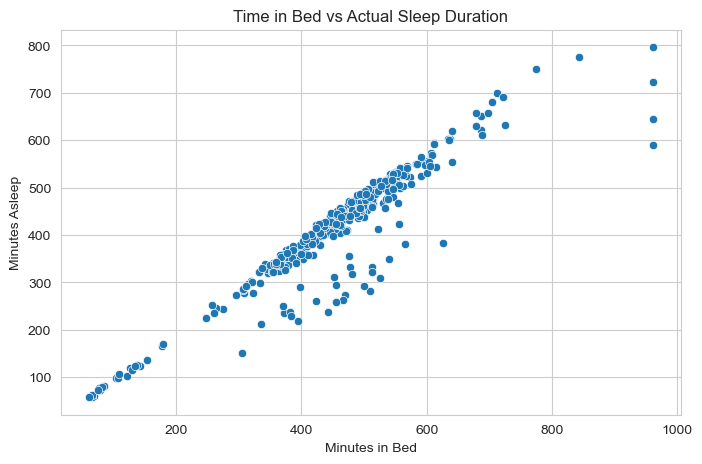

In [52]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged_data,
    x="TotalTimeInBed",
    y="TotalMinutesAsleep"
)

plt.title("Time in Bed vs Actual Sleep Duration")
plt.xlabel("Minutes in Bed")
plt.ylabel("Minutes Asleep")

plt.show()

In [57]:
merged_daily = pd.merge(
    merged_data,
    weight_clean,
    how="left",
    on=["Id","Date"]
)

merged_daily.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,HoursAsleep,HoursInBed,SleepEfficiency,WeightKg,WeightPounds,BMI
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,...,2016-04-12,1,327,346,5.450000,5.766667,0.945087,NaN,NaN,NaN
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,2016-04-13,2,384,407,6.400000,6.783333,0.943489,NaN,NaN,NaN
2,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,...,2016-04-15,1,412,442,6.866667,7.366667,0.932127,NaN,NaN,NaN
3,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,...,2016-04-16,2,340,367,5.666667,6.116667,0.926431,NaN,NaN,NaN
4,1503960366,2016-04-17,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,...,2016-04-17,1,700,712,11.666667,11.866667,0.983146,NaN,NaN,NaN


In [58]:
merged_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        410 non-null    int64         
 1   ActivityDate              410 non-null    datetime64[ns]
 2   TotalSteps                410 non-null    int64         
 3   TotalDistance             410 non-null    float64       
 4   TrackerDistance           410 non-null    float64       
 5   LoggedActivitiesDistance  410 non-null    float64       
 6   VeryActiveDistance        410 non-null    float64       
 7   ModeratelyActiveDistance  410 non-null    float64       
 8   LightActiveDistance       410 non-null    float64       
 9   SedentaryActiveDistance   410 non-null    float64       
 10  VeryActiveMinutes         410 non-null    int64         
 11  FairlyActiveMinutes       410 non-null    int64         
 12  LightlyActiveMinutes  

## Merge Hourly Activity Datasets

In [59]:
merged_hourly = hourly_steps.merge(
    hourly_calories,
    on=["Id", "ActivityHour"]
)

merged_hourly = merged_hourly.merge(
    hourly_intensities,
    on=["Id", "ActivityHour"]
)

merged_hourly.head()

,Id,ActivityHour,StepTotal,Hour_x,DayOfWeek,Calories,Hour_y,TotalIntensity,AverageIntensity,Hour
0,1503960366,2016-04-12 00:00:00,373,0,Tuesday,81,0,20,0.333333,0
1,1503960366,2016-04-12 01:00:00,160,1,Tuesday,61,1,8,0.133333,1
2,1503960366,2016-04-12 02:00:00,151,2,Tuesday,59,2,7,0.116667,2
3,1503960366,2016-04-12 03:00:00,0,3,Tuesday,47,3,0,0.000000,3
4,1503960366,2016-04-12 04:00:00,0,4,Tuesday,48,4,0,0.000000,4


In [60]:
merged_hourly = merged_hourly[
[
"Id",
"ActivityHour",
"DayOfWeek",
"Hour",
"StepTotal",
"Calories",
"TotalIntensity",
"AverageIntensity"
]
]

In [61]:
merged_hourly.info()
merged_hourly.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Id                22099 non-null  int64         
 1   ActivityHour      22099 non-null  datetime64[ns]
 2   DayOfWeek         22099 non-null  object        
 3   Hour              22099 non-null  int32         
 4   StepTotal         22099 non-null  int64         
 5   Calories          22099 non-null  int64         
 6   TotalIntensity    22099 non-null  int64         
 7   AverageIntensity  22099 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int32(1), int64(4), object(1)
memory usage: 1.3+ MB


,Id,ActivityHour,DayOfWeek,Hour,StepTotal,Calories,TotalIntensity,AverageIntensity
0,1503960366,2016-04-12 00:00:00,Tuesday,0,373,81,20,0.333333
1,1503960366,2016-04-12 01:00:00,Tuesday,1,160,61,8,0.133333
2,1503960366,2016-04-12 02:00:00,Tuesday,2,151,59,7,0.116667
3,1503960366,2016-04-12 03:00:00,Tuesday,3,0,47,0,0.000000
4,1503960366,2016-04-12 04:00:00,Tuesday,4,0,48,0,0.000000


## Relationship Between Body Weight and Daily Activity

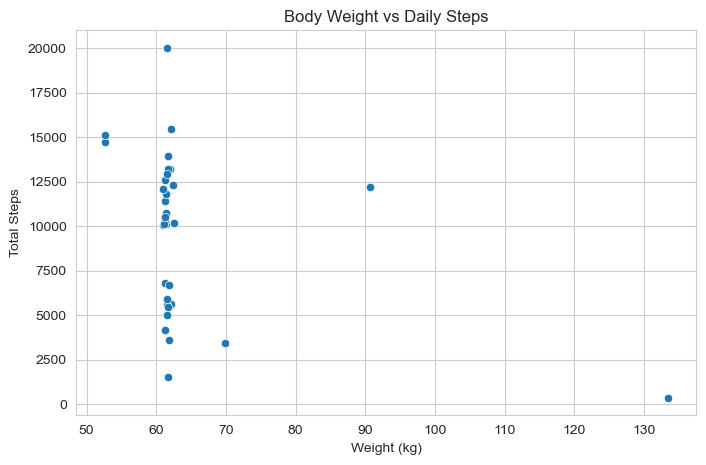

In [62]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged_daily,
    x="WeightKg",
    y="TotalSteps"
)

plt.title("Body Weight vs Daily Steps")
plt.xlabel("Weight (kg)")
plt.ylabel("Total Steps")

plt.show()

# Cross-Dataset Behavioral Insights

1. **Sleep duration is strongly driven by time spent in bed**

The relationship between time spent in bed and actual sleep duration shows a very strong linear pattern. Most observations lie close to the diagonal line, indicating that users generally sleep for the majority of the time they spend in bed. This suggests relatively high sleep efficiency among most users in the dataset.

2. **Higher sedentary time is associated with shorter sleep duration**

The sedentary vs sleep plot shows a downward trend where higher sedentary minutes correspond to lower sleep duration. Users with extremely high sedentary time (above ~1000 minutes per day) tend to report significantly lower sleep durations. This suggests that highly inactive lifestyles may negatively affect sleep behavior.

3. **Daily physical activity does not show a strong direct relationship with sleep duration**

The relationship between daily step count and sleep duration appears scattered without a clear linear trend. Users with both low and high step counts show a wide range of sleep durations. This indicates that while physical activity contributes to overall health, it may not directly determine the number of hours slept.

4. **Weight data is sparsely recorded and shows no clear relationship with daily steps**

The body weight vs daily steps plot contains relatively few observations because only a small subset of users recorded weight data. Among the available records, there is no strong visible relationship between body weight and daily step count, suggesting that body weight alone may not explain daily movement levels in this dataset.

5. **User behavior patterns suggest that lifestyle factors are multifaceted**

Across the combined datasets, activity levels, sedentary time, sleep duration, and body weight do not appear to be determined by a single dominant factor. Instead, these behaviors likely interact in complex ways influenced by lifestyle, routine, and individual habits.

In [65]:
merged_daily.to_csv("merged_daily.csv", index=False)
merged_hourly.to_csv("merged_hourly.csv", index=False)

In [68]:
import os
os.startfile(os.getcwd())

In [69]:
import os
print(os.getcwd())

C:\Users\lenovo\anaconda_projects\Strava_Fitness_Project
